<a href="https://colab.research.google.com/github/dodi-ctrl/PhishingDetector/blob/main/URL_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/dodi-ctrl/PhishingDetector/blob/main/URL_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# URL Agent — Multi-Corpus Training

Trains the Random Forest URL agent on URLs embedded in **the same three email corpora** as the Metadata Agent and the augmented DistilBERT text agent. This keeps the training data consistent across all three agents.

| Source | Label | Provides |
|---|---|---|
| `phishing_pot` (GitHub) | phishing (1) | URLs inside modern 2022–2024 phishing emails |
| Nazario `phishing3.mbox` (≥2022) | phishing (1) | URLs from honeypot phishing |
| Enron ham via HuggingFace | legitimate (0) | URLs inside legitimate corporate mail |

In [10]:
# Install dependencies
!pip install -q datasets scikit-learn pandas numpy matplotlib seaborn joblib
print("Installation OK")

Installation OK


In [11]:
# Clone the repo
import os

if not os.path.exists('PhishingDetector'):
    !git clone https://github.com/dodi-ctrl/PhishingDetector.git

os.chdir('PhishingDetector')
print("Working directory:", os.getcwd())
print("Files:", os.listdir('.'))

Cloning into 'PhishingDetector'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 88 (delta 48), reused 55 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 212.28 KiB | 8.49 MiB/s, done.
Resolving deltas: 100% (48/48), done.
Working directory: /content/PhishingDetector/PhishingDetector
Files: ['Data Sets Update.docx', 'Metadata_Agent.ipynb', 'email_preprocessing.py', 'dataset_handling.py', 'feature_extraction.py', 'metadata_agent.py', 'url_agent.py', '.git', 'DistilBERT_Phishing_Text_Agent.ipynb', '.gitignore', 'URL_Agent.ipynb']


## Download phishing corpora

- **phishing_pot**: cloned from GitHub — thousands of recent .eml files in `phishing_pot/email/`.
- **Nazario phishing3.mbox**: ~3,000 phishing messages.
- **Enron ham** is fetched on demand from HuggingFace inside `build_eml_corpus`.

In [12]:
import os

if not os.path.exists('phishing_pot'):
    !git clone --depth 1 https://github.com/rf-peixoto/phishing_pot.git
if not os.path.exists('phishing3.mbox'):
    !wget -q https://monkey.org/~jose/phishing/phishing3.mbox

for f in ('phishing_pot', 'phishing3.mbox'):
    print(f'  {f}: {"OK" if os.path.exists(f) else "MISSING"}')

Cloning into 'phishing_pot'...
remote: Enumerating objects: 7919, done.
remote: Counting objects: 100% (7919/7919), done.
remote: Compressing objects: 100% (6132/6132), done.
remote: Total 7919 (delta 1796), reused 6589 (delta 1783), pack-reused 0 (from 0)
Receiving objects: 100% (7919/7919), 126.93 MiB | 17.90 MiB/s, done.
Resolving deltas: 100% (1796/1796), done.
Updating files: 100% (7916/7916), done.
  phishing_pot: OK
  phishing3.mbox: OK


In [13]:
# Build EML corpus (for email-embedded URLs)
from dataset_handling import build_eml_corpus, build_url_corpus, extract_url_features_from_url_corpus
from feature_extraction import FeatureExtractor

PHISHING_DIRS = ['phishing_pot/email', 'phishing_pot/emails']
PHISHING_MBOX = ['phishing3.mbox']
ENRON_MAX     = 5000

eml_df = build_eml_corpus(
    phishing_dirs=PHISHING_DIRS,
    phishing_mbox_paths=PHISHING_MBOX,
    enron_max=ENRON_MAX,
    nazario_after_year=2022,
)


BUILDING EML CORPUS (phishing_pot + Nazario + Enron)
  Loaded 7911 .eml files from phishing_pot/email (label=1)
  Loaded 1 messages from phishing3.mbox (label=1)
  Loading Enron ham from HuggingFace (SetFit/enron_spam)...


Repo card metadata block was not found. Setting CardData to empty.


  Loaded 5000 Enron ham emails (label=0)

✓ EML corpus built:
  Phishing:   7912
  Legitimate: 5000
  Total:      12912
  Sources:    {'phishing_pot': 7911, 'enron': 5000, 'nazario': 1}


In [14]:
import os
import urllib.request
import zipfile

if not os.path.exists('top-1m.csv'):
    print("Downloading Cisco Umbrella top-1m domain list...")
    url = "https://s3-us-west-1.amazonaws.com/umbrella-static/top-1m.csv.zip"
    urllib.request.urlretrieve(url, "top-1m.csv.zip")
    with zipfile.ZipFile("top-1m.csv.zip", "r") as z:
        z.extractall(".")
    print("✓ Umbrella top-1m downloaded")
else:
    print("✓ Umbrella top-1m already present")

✓ Umbrella top-1m downloaded


In [15]:
# Build the URL corpus from .eml bodies
from dataset_handling import build_url_corpus, extract_url_features_from_url_corpus

url_df = build_url_corpus(
    eml_df=eml_df,
    phishtank_csv=None,
    umbrella_csv='top-1m.csv',
    umbrella_limit=10000,
)


BUILDING URL CORPUS (EML + PhishTank + Umbrella)
  Extracting URLs from EML corpus...
  Extracted 6074 URLs from EML corpus
  Loaded 10000 legitimate domains from Umbrella top-1M

✓ URL corpus built:
  Phishing:   6074
  Legitimate: 10000
  Total:      16074
  Sources:    {'umbrella': 10000, 'eml_phishing_pot': 6074}


In [16]:
# Extract URL features
extractor = FeatureExtractor()
features_df, labels = extract_url_features_from_url_corpus(url_df, extractor)

print('\nFeature matrix shape:', features_df.shape)
print('URL feature columns:', features_df.columns.tolist())


EXTRACTING URL FEATURES FROM URL CORPUS
  Processed 5000/16074 URLs...
  Processed 10000/16074 URLs...
  Processed 15000/16074 URLs...

✓ Extracted 23 URL features from 16074 entries

Feature matrix shape: (16074, 23)
URL feature columns: ['url_count', 'has_urls', 'excessive_urls', 'domain_has_ip', 'domain_has_hyphen', 'domain_has_at_symbol', 'excessive_subdomains', 'domain_has_suspicious_tld', 'domain_length_suspicious', 'possible_brand_spoofing', 'path_has_suspicious_keywords', 'url_has_encoding', 'url_has_redirection', 'has_query_params', 'uses_non_standard_port', 'is_shortened_url', 'potential_typosquatting', 'domain_length', 'domain_dots_count', 'path_length', 'query_param_count', 'suspicious_param_count', 'uses_https']


In [17]:
# Train / test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_df, labels,
    test_size=0.3,
    random_state=42,
    stratify=labels,
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"  - Legitimate:   {(y_test == 0).sum()}")
print(f"  - Phishing:     {(y_test == 1).sum()}")

Training samples: 11251
Test samples:     4823
  - Legitimate:   3000
  - Phishing:     1823


In [18]:
# Train the URL Agent
from url_agent import URLAgent

agent = URLAgent(n_estimators=100, max_depth=20, random_state=42)
agent.train(X_train, y_train, validate=True, tune_hyperparameters=False)


TRAINING URL AGENT (Random Forest)

Performing 5-fold cross-validation...
Cross-validation Accuracy: 0.9928 (+/- 0.0026)
Cross-validation F1-Score: 0.9904 (+/- 0.0035)

----------------------------------------------------------------------
TOP URL FEATURES BY IMPORTANCE
----------------------------------------------------------------------
path_length                         0.678756
has_query_params                    0.080891
query_param_count                   0.077836
uses_https                          0.048834
domain_length                       0.030753
domain_has_hyphen                   0.027038
domain_dots_count                   0.018983
excessive_subdomains                0.008887
url_has_encoding                    0.007936
domain_length_suspicious            0.007612
suspicious_param_count              0.004369
possible_brand_spoofing             0.002247
uses_non_standard_port              0.001696
is_shortened_url                    0.001447
path_has_suspicious_keyword


URL AGENT PERFORMANCE EVALUATION

Accuracy:  0.9934 (99.34%)
Precision: 1.0000 (100.00%)
Recall:    0.9824 (98.24%)
F1-Score:  0.9911 (99.11%)
ROC-AUC:   0.9969

False Positive Rate (FPR): 0.0000 (0.00%)
False Negative Rate (FNR): 0.0176 (1.76%)
True Negative Rate (TNR):  1.0000 (100.00%)

----------------------------------------------------------------------
CONFUSION MATRIX
----------------------------------------------------------------------
                Predicted Legit Predicted Phishing
Actual Legit               3000                  0
Actual Phishing              32               1791

----------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate     0.9894    1.0000    0.9947      3000
    Phishing     1.0000    0.9824    0.9911      1823

    accuracy                         0.9934      4823
   m

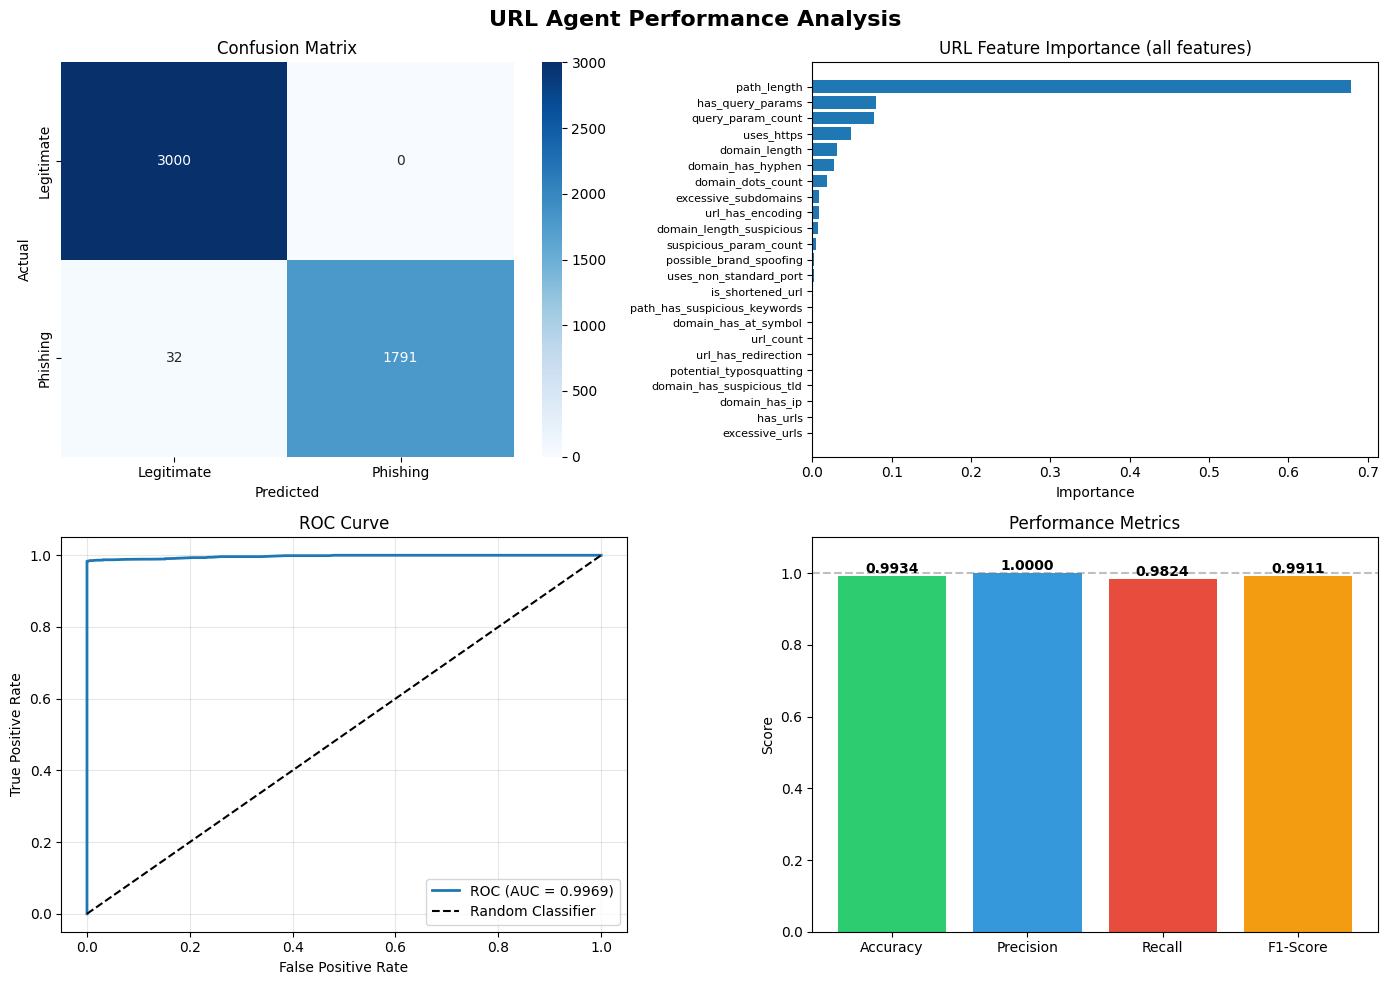

In [19]:
# Evaluate — accuracy, precision, recall, F1, ROC-AUC, FPR/FNR/TNR,
# confusion matrix, classification report, and plots
results = agent.evaluate(X_test, y_test, plot_results=True)

In [20]:
# Save model and results
agent.save_model('url_agent.pkl')
agent.export_results(results, 'url_agent_results.json')

print('\n' + '=' * 70)
print('Training complete!')
print(f"  Accuracy:  {results['accuracy']:.4f}")
print(f"  F1-Score:  {results['f1_score']:.4f}")
print(f"  ROC-AUC:   {results['roc_auc']:.4f}")
print('=' * 70)


✓ Model saved successfully to: url_agent.pkl

✓ Results exported to: url_agent_results.json

Training complete!
  Accuracy:  0.9934
  F1-Score:  0.9911
  ROC-AUC:   0.9969
